In [56]:
from ortools.linear_solver import pywraplp
solver = pywraplp.Solver.CreateSolver('SCIP')
#판매가격 
SMP=[5]*6+[10]*4+[15]*6+[10]*4+[5]*4
#REC for 태양광발전 저장용 배터리
RPV=[0]*10+[5]*6+[0]*8
#태양광 전력 생산량
FPV=[0]*6 + [0.4, 0.8, 1.4, 2.2, 2.8, 3.0, 2.8, 2.6, 2.2, 1.6, 1.0, 0.4, 0.2] + [0]*5
BigM=100000
nTimes=24
infinity = solver.infinity()

#i시간대 전력 판매량
X = {}
for i in range(nTimes):
    X[i] = solver.NumVar(0, infinity, 'X[%i]' % i)
#i시간대 충전량/방전량
QCPV,QDPV = {}, {}
for i in range(nTimes):
    QCPV[i] = solver.NumVar(0, infinity, 'QCPV[%i]' % i)
    QDPV[i] = solver.NumVar(0, infinity, 'QDPV[%i]' % i)
#i시간대 ESS 량
ESS = {}
for i in range(nTimes+1):
    ESS[i] = solver.NumVar(0, infinity, 'ESS[%i]' % i)
#충전 or 방전 여부
Y1,Y2= {}, {}
for i in range(nTimes):
    Y1[i] = solver.BoolVar('Y1[%i]' % i)
    Y2[i] = solver.BoolVar('Y2[%i]' % i)
#충전량=max(발전량-판매량,0)에서 발전량-판매량>=0 or 발전량-판매량<0 여부부
Z1,Z2= {}, {}
for i in range(nTimes):
    Z1[i] = solver.BoolVar('Z1[%i]' % i)
    Z2[i] = solver.BoolVar('Z2[%i]' % i)


In [57]:
#제약식 1: 전체 판매량은 발전량과 저장량의 합을 넘을 수 없음음
for i in range(nTimes):
    solver.Add(X[i]<=FPV[i]+ESS[i],'c1_'+str(i))
#제약식2: time t에너지량= time t-1에너지량 + 충전량 - 방전량
for i in range(nTimes):
    solver.Add(ESS[i+1]==ESS[i]+QCPV[i]-QDPV[i],'c2_'+str(i))
#제약식3: 시간 t에서 충전 또는 방전 한 가지만 가능
for i in range(nTimes):
    solver.Add(QCPV[i]<=BigM*Y1[i],'c3_'+str(i))
    solver.Add(QDPV[i]<=BigM*Y2[i],'c4_'+str(i))
    solver.Add(Y1[i]+Y2[i]<=1,'c5_'+str(i))
#제약식4: 충전량=max(발전량-판매량,0)에서 발전량-판매량>=0 or 발전량-판매량<0 여부
#충전량이 음수가 되는 경우는 없지만 수학적 모델링에서 'max'를 표현하기 위해 다음과 같은 제약식을 추가함
for i in range(nTimes):
    solver.Add(QCPV[i]>=FPV[i]-X[i], 'c6_'+str(i))
    solver.Add(QCPV[i]<=BigM*Z1[i] ,'c7_'+str(i))
    solver.Add(QCPV[i]<=FPV[i]-X[i]+BigM*Z2[i] ,'c8_'+str(i))
    solver.Add(Z1[i]+Z2[i]==1,'c9_'+str(i))
#제약식5: 판매량-발전량 부분은 에너지 저장장치 방전에서 채워져야 함
for i in range(nTimes):
    solver.Add(QDPV[i]>=X[i]-FPV[i],'c10_'+str(i))
#제약식6: ESS 초기 저장량
solver.Add(ESS[0]==0,'c11')
#제약식7: ESS 최대 저장량 10MW
for i in range(nTimes+1):
    solver.Add(ESS[i]<=10,'c12_'+str(i))
#제약식8: 충전량, 방전량 최대 10MW
for i in range(nTimes):
    solver.Add(QCPV[i]<=10,'c13_'+str(i))
    solver.Add(QDPV[i]<=10,'c14_'+str(i))
solver.Maximize(solver.Sum([SMP[i]*X[i] + RPV[i]*QCPV[i] for i in 
range(nTimes)]))

In [58]:
# Solve
status = solver.Solve()

data_x, data_qcpv, data_qdpv, data_ess = [], [], [], []

# Print solution
if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
    print(f"전력 판매수익 = {solver.Objective().Value():.1f}\n")

    print('전력 판매량:')
    for i in range(nTimes):
        val = X[i].solution_value()
        data_x.append(val)
        if val > 1e-7:
            print(f"\tX[{i}] = {val:.2f}")

    print('전력 충전량:')
    for i in range(nTimes):
        val = QCPV[i].solution_value()
        data_qcpv.append(val)
        if val > 1e-7:
            print(f"\tQCPV[{i}] = {val:.2f}")

    print('전력 방전량:')
    for i in range(nTimes):
        val = QDPV[i].solution_value()
        data_qdpv.append(val)
        if val > 1e-7:
            print(f"\tQDPV[{i}] = {val:.2f}")

    print('ESS 상태:')
    for i in range(nTimes + 1):
        val = ESS[i].solution_value()
        data_ess.append(val)
        if val > 1e-7:
            print(f"\tESS[{i}] = {val:.2f}")
else:
    print("No solution found.")


전력 판매수익 = 365.0

전력 판매량:
	X[11] = 8.20
	X[15] = 11.60
	X[16] = 1.00
	X[17] = 0.40
	X[18] = 0.20
전력 충전량:
	QCPV[6] = 0.40
	QCPV[7] = 0.80
	QCPV[8] = 1.40
	QCPV[9] = 2.20
	QCPV[10] = 2.80
	QCPV[12] = 2.80
	QCPV[13] = 2.60
	QCPV[14] = 2.20
전력 방전량:
	QDPV[11] = 5.20
	QDPV[15] = 10.00
ESS 상태:
	ESS[7] = 0.40
	ESS[8] = 1.20
	ESS[9] = 2.60
	ESS[10] = 4.80
	ESS[11] = 7.60
	ESS[12] = 2.40
	ESS[13] = 5.20
	ESS[14] = 7.80
	ESS[15] = 10.00


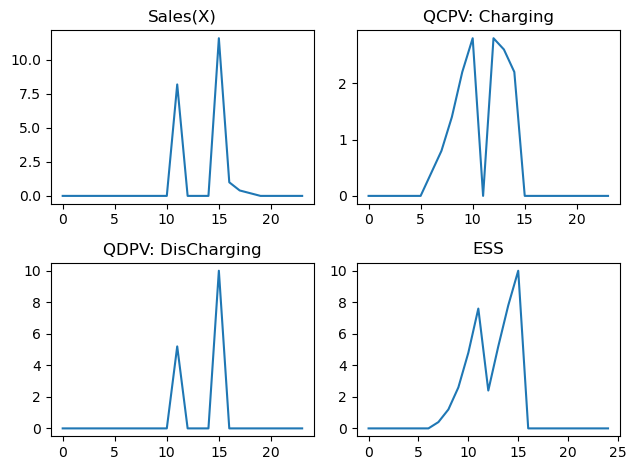

In [59]:
import matplotlib.pyplot as plt
plt.subplot(221)
plt.plot(data_x)
plt.title('Sales(X)')
plt.subplot(222)
plt.plot(data_qcpv)
plt.title('QCPV: Charging')
plt.subplot(223)
plt.plot(data_qdpv)
plt.title('QDPV: DisCharging')
plt.subplot(224)
plt.plot(data_ess)
plt.title('ESS')
plt.tight_layout()
plt.show()


In [60]:
RWT=[0]*8+[5]*4+[0]*12
FWT=[1]*12+[2]*12
#i시간대 전력 판매량
X = {}
for i in range(nTimes):
    X[i] = solver.NumVar(0, infinity, 'X[%i]' % i)
#i시간대 충전량/방전량
QCWT,QDWT = {}, {}
for i in range(nTimes):
    QCWT[i] = solver.NumVar(0, infinity, 'QCPV[%i]' % i)
    QDWT[i] = solver.NumVar(0, infinity, 'QDPV[%i]' % i)
#i시간대 ESS 량
ESS = {}
for i in range(nTimes+1):
    ESS[i] = solver.NumVar(0, infinity, 'ESS[%i]' % i)
#충전 or 방전 여부
Y1,Y2= {}, {}
for i in range(nTimes):
    Y1[i] = solver.BoolVar('Y1[%i]' % i)
    Y2[i] = solver.BoolVar('Y2[%i]' % i)
#충전량=max(발전량-판매량,0)에서 발전량-판매량>=0 or 발전량-판매량<0 여부부
Z1,Z2= {}, {}
for i in range(nTimes):
    Z1[i] = solver.BoolVar('Z1[%i]' % i)
    Z2[i] = solver.BoolVar('Z2[%i]' % i)
#제약식 1: 전체 판매량은 발전량과 저장량의 합을 넘을 수 없음음
for i in range(nTimes):
    solver.Add(X[i]<=FWT[i]+ESS[i],'c1_'+str(i))
#제약식2: time t에너지량= time t-1에너지량 + 충전량 - 방전량
for i in range(nTimes):
    solver.Add(ESS[i+1]==ESS[i]+QCWT[i]-QDWT[i],'c2_'+str(i))
#제약식3: 시간 t에서 충전 또는 방전 한 가지만 가능
for i in range(nTimes):
    solver.Add(QCWT[i]<=BigM*Y1[i],'c3_'+str(i))
    solver.Add(QDWT[i]<=BigM*Y2[i],'c4_'+str(i))
    solver.Add(Y1[i]+Y2[i]<=1,'c5_'+str(i))
#제약식4: 충전량=max(발전량-판매량,0)에서 발전량-판매량>=0 or 발전량-판매량<0 여부
#충전량이 음수가 되는 경우는 없지만 수학적 모델링에서 'max'를 표현하기 위해 다음과 같은 제약식을 추가함
for i in range(nTimes):
    solver.Add(QCWT[i]>=FWT[i]-X[i], 'c6_'+str(i))
    solver.Add(QCWT[i]<=BigM*Z1[i] ,'c7_'+str(i))
    solver.Add(QCWT[i]<=FWT[i]-X[i]+BigM*Z2[i] ,'c8_'+str(i))
    solver.Add(Z1[i]+Z2[i]<=1,'c9_'+str(i))
#제약식5: 판매량-발전량 부분은 에너지 저장장치 방전에서 채워져야 함
for i in range(nTimes):
    solver.Add(QDWT[i]>=X[i]-FWT[i],'c10_'+str(i))
#제약식6: ESS 초기 저장량
solver.Add(ESS[0]==0,'c11')
#제약식7: ESS 최대 저장량 10MW
for i in range(nTimes+1):
    solver.Add(ESS[i]<=10,'c12_'+str(i))
#제약식8: 충전량, 방전량 최대 10MW
for i in range(nTimes):
    solver.Add(QCWT[i]<=10,'c13_'+str(i))
    solver.Add(QDWT[i]<=10,'c14_'+str(i))
solver.Maximize(solver.Sum([SMP[i]*X[i] + RWT[i]*QDWT[i] for i in 
range(nTimes)]))

In [62]:
# Solve
status = solver.Solve()
data_x, data_qcwt, data_qdwt, data_ess = [], [], [], []

# Print solution
if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
    print(f"전력 판매수익 = {solver.Objective().Value():.1f}\n")

    print("전력 판매량:")
    for i in range(nTimes):
        val = X[i].solution_value()
        data_x.append(val)
        if val > 1e-7:
            print(f"\tX[{i}] = {val:.2f}")

    print("전력 충전량:")
    for i in range(nTimes):
        val = QCWT[i].solution_value()
        data_qcwt.append(val)
        if val > 1e-7:
            print(f"\tQCWT[{i}] = {val:.2f}")

    print("전력 방전량:")
    for i in range(nTimes):
        val = QDWT[i].solution_value()
        data_qdwt.append(val)
        if val > 1e-7:
            print(f"\tQDWT[{i}] = {val:.2f}")

    print("ESS 상태:")
    for i in range(nTimes + 1):
        val = ESS[i].solution_value()
        data_ess.append(val)
        if val > 1e-7:
            print(f"\tESS[{i}] = {val:.2f}")
else:
    print("No solution found.")


전력 판매수익 = 470.0

전력 판매량:
	X[10] = 1.00
	X[11] = 11.00
	X[12] = 2.00
	X[13] = 2.00
	X[14] = 2.00
	X[15] = 2.00
	X[16] = 2.00
	X[17] = 2.00
	X[18] = 2.00
	X[19] = 2.00
	X[20] = 2.00
	X[21] = 2.00
	X[22] = 2.00
	X[23] = 2.00
전력 충전량:
	QCWT[0] = 1.00
	QCWT[1] = 1.00
	QCWT[2] = 1.00
	QCWT[3] = 1.00
	QCWT[4] = 1.00
	QCWT[5] = 1.00
	QCWT[6] = 1.00
	QCWT[7] = 1.00
	QCWT[8] = 1.00
	QCWT[9] = 1.00
전력 방전량:
	QDWT[11] = 10.00
ESS 상태:
	ESS[1] = 1.00
	ESS[2] = 2.00
	ESS[3] = 3.00
	ESS[4] = 4.00
	ESS[5] = 5.00
	ESS[6] = 6.00
	ESS[7] = 7.00
	ESS[8] = 8.00
	ESS[9] = 9.00
	ESS[10] = 10.00
	ESS[11] = 10.00
